In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import List

plt.style.use('seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default')

class DataLoader:
    """
    Módulo para la adquisición, validación y sincronización
    de series temporales financieras.

    Puede utilizarse tanto para:

    - Precios de activos (ETFs)
    - Tasas financieras (^IRX)
    """

    def __init__(self, tickers: List[str], start_date: str, end_date: str):
        self.tickers = sorted(tickers)
        self.start_date = start_date
        self.end_date = end_date

        self.raw_data: pd.DataFrame = None
        self.adj_close: pd.DataFrame = None

# Descarga
    def fetch_data(self) -> pd.DataFrame:
        """
        Descarga los datos históricos utilizando Yahoo Finance.
        Se mantiene auto_adjust=False para conservar Adj Close.
        """

        print(f"Descargando datos para: {self.tickers} "
f"desde {self.start_date} hasta {self.end_date}..." )

        data = yf.download(tickers=self.tickers, start=self.start_date, end=self.end_date,
            auto_adjust=False, progress=False)

    # Validación
        if isinstance(data.columns, pd.MultiIndex):

            self.raw_data = data

            # Extraemos únicamente Adjusted Close
            self.adj_close = data['Adj Close'].copy()

        else:

            # Caso de un solo ticker
            self.adj_close = pd.DataFrame(
                data['Adj Close']
            )

            self.adj_close.columns = self.tickers

        return self.adj_close

    def validate_and_clean(self, validate_positive: bool = True) -> pd.DataFrame:
        """
        Limpia y valida las series temporales.

        Parámetros
        ----------
        validate_positive : bool
            True  -> exige que todos los valores sean > 0.
                    Adecuado para precios de activos.

            False -> no aplica la validación de positividad.
                    Útil para variables como tasas de interés.

        """

        if self.adj_close is None:
            raise ValueError(
                "No hay datos cargados. "
                "Ejecuta fetch_data() antes de validate_and_clean().")

        df = self.adj_close.copy()

        for column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')

        df = df.sort_index()

        initial_nans = df.isna().sum()

        if initial_nans.any():

            print("\nValores nulos detectados por activo "
                "antes de imputación:")

            print(initial_nans[initial_nans > 0])

        df = df.ffill()
        df = df.bfill()

        # Validación de valores positivos
        if validate_positive:

            if (df <= 0).any().any():

                invalid_assets = df.columns[
                    (df <= 0).any()
                ].tolist()

                raise ValueError(f"Precios no positivos detectados en: "
                    f"{invalid_assets}")

        # Validación final de NaN

        if df.isna().any().any():

            invalid_columns = df.columns[df.isna().any()].tolist()

            raise ValueError(
                f"Existen valores NaN persistentes en: "
                f"{invalid_columns}")

        # Guardar datos limpios
        self.adj_close = df
        print(
            f"Limpieza completada con éxito. "
            f"Dimensiones del dataset: "
            f"{self.adj_close.shape}")

        return self.adj_close


    # RESUMEN DE CALIDAD DE DATOS
    def get_summary_stats(self) -> pd.DataFrame:
        """
        Genera un resumen de sanidad de los datos.
        """

        summary = pd.DataFrame({

            "Primer Registro":
                self.adj_close.apply(
                    lambda col:
                    col.first_valid_index().strftime('%Y-%m-%d')
                ),

            "Último Registro":
                self.adj_close.apply(
                    lambda col:
                    col.last_valid_index().strftime('%Y-%m-%d')),

            "Observaciones":
                self.adj_close.count(),

            "Min Price ($)":
                self.adj_close.min().round(2),

            "Max Price ($)":
                self.adj_close.max().round(2)})

        return summary


# 2. DEFINICIÓN DEL UNIVERSO DE ACTIVOS

ASSETS = ['SPY', 'IWM', 'EFA', 'EEM', 'AGG', 'TLT', 'GLD','VNQ']

START_DATE = '2014-01-01'
END_DATE = '2024-01-01'


# INGESTA DE ETFs

loader = DataLoader(tickers=ASSETS, start_date=START_DATE,end_date=END_DATE)
raw_prices = loader.fetch_data()
clean_prices = loader.validate_and_clean(
    validate_positive=True)
# RESUMEN DE CALIDAD DE DATOS

print("\n--- Auditoría de Sanidad de Datos ---")
print(loader.get_summary_stats())

#  DESCARGA DE LA TASA LIBRE DE RIESGO
rf_loader = DataLoader(tickers=['^IRX'], start_date=START_DATE, end_date=END_DATE)
rf_raw = rf_loader.fetch_data()

rf_clean = rf_loader.validate_and_clean(validate_positive=False)
rf_series = rf_clean['^IRX'] / 100.0

# RESUMEN DE LA TASA LIBRE DE RIESGO

print("\n--- Resumen de ^IRX ---")
print(rf_clean.describe())
print("\nPrimeros valores de la tasa libre de riesgo:")
print(rf_series.head())

Descargando datos para: ['AGG', 'EEM', 'EFA', 'GLD', 'IWM', 'SPY', 'TLT', 'VNQ'] desde 2014-01-01 hasta 2024-01-01...
Limpieza completada con éxito. Dimensiones del dataset: (2516, 8)

--- Auditoría de Sanidad de Datos ---
       Primer Registro Último Registro  Observaciones  Min Price ($)  \
Ticker                                                                 
AGG         2014-01-02      2023-12-29           2516          75.33   
EEM         2014-01-02      2023-12-29           2516          22.51   
EFA         2014-01-02      2023-12-29           2516          37.50   
GLD         2014-01-02      2023-12-29           2516         100.50   
IWM         2014-01-02      2023-12-29           2516          82.92   
SPY         2014-01-02      2023-12-29           2516         141.11   
TLT         2014-01-02      2023-12-29           2516          71.92   
VNQ         2014-01-02      2023-12-29           2516          39.36   

        Max Price ($)  
Ticker                 
AGG     

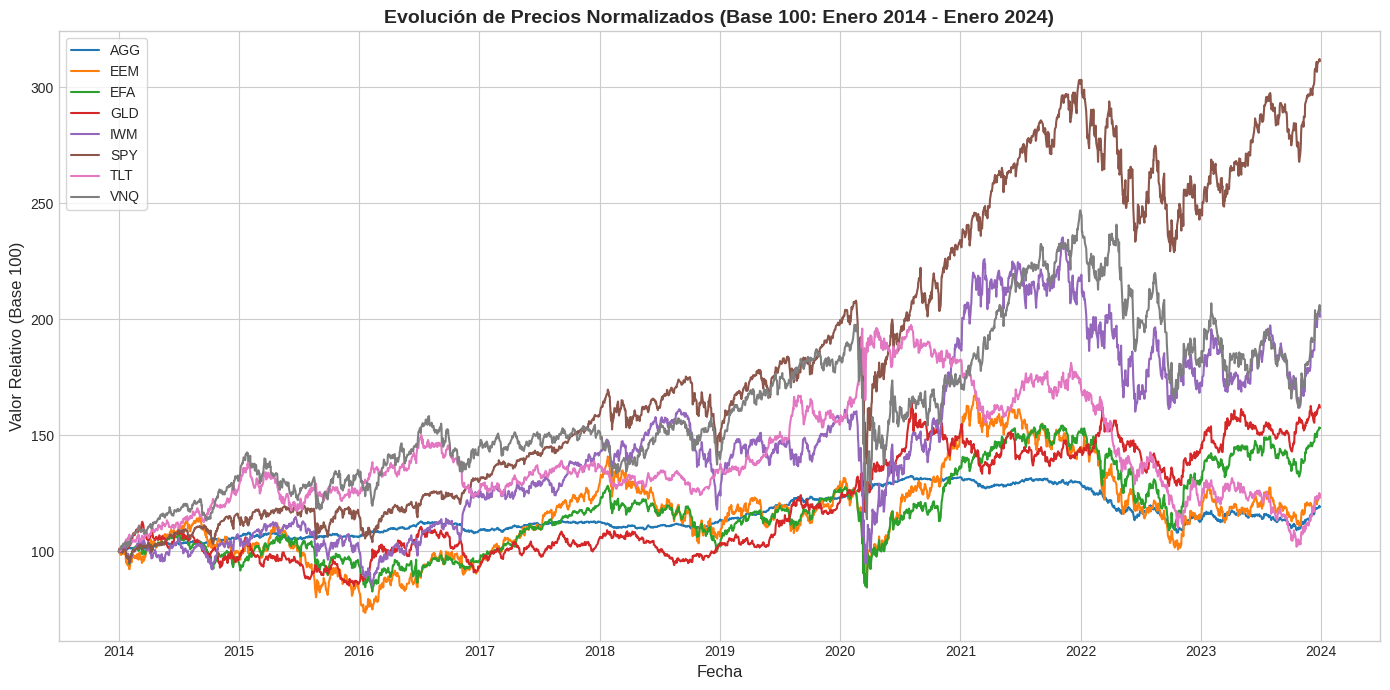

In [2]:
def plot_normalized_series(prices: pd.DataFrame):
    """Normaliza las series a Base 100 (t=0) para comparar dinámicas relativas."""
    normalized = (prices / prices.iloc[0]) * 100

    plt.figure(figsize=(14, 7))
    for col in normalized.columns:
        plt.plot(normalized.index, normalized[col], label=col, linewidth=1.5)

    plt.title("Evolución de Precios Normalizados (Base 100: Enero 2014 - Enero 2024)", fontsize=14, fontweight='bold')
    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel("Valor Relativo (Base 100)", fontsize=12)
    plt.legend(loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()

plot_normalized_series(clean_prices)

--- Parámetros In-Sample (2014-01-02 a 2020-12-31) ---
Tasa Libre de Riesgo Anualizada Promedio (Rf): 0.7971%

--- Tabla Estadística Descriptiva (Sin Sesgo de Look-Ahead) ---
     Rendimiento Medio Anual  Volatilidad Anual (σ)  Sharpe Ratio Ex-Ante  Max Drawdown  Asimetría (Skew)  Exceso de Curtosis  Jarque-Bera p-valor  ¿Es Normal? (α=0.05)
AGG                   0.0406                 0.0425                0.7690       -0.0958           -3.4224             67.6479                  0.0                 False
EEM                   0.0802                 0.2126                0.3396       -0.3820           -1.0558             10.6315                  0.0                 False
EFA                   0.0590                 0.1743                0.2926       -0.3419           -1.6678             19.7807                  0.0                 False
GLD                   0.0690                 0.1409                0.4332       -0.2449           -0.0756              3.7080                  0.0   

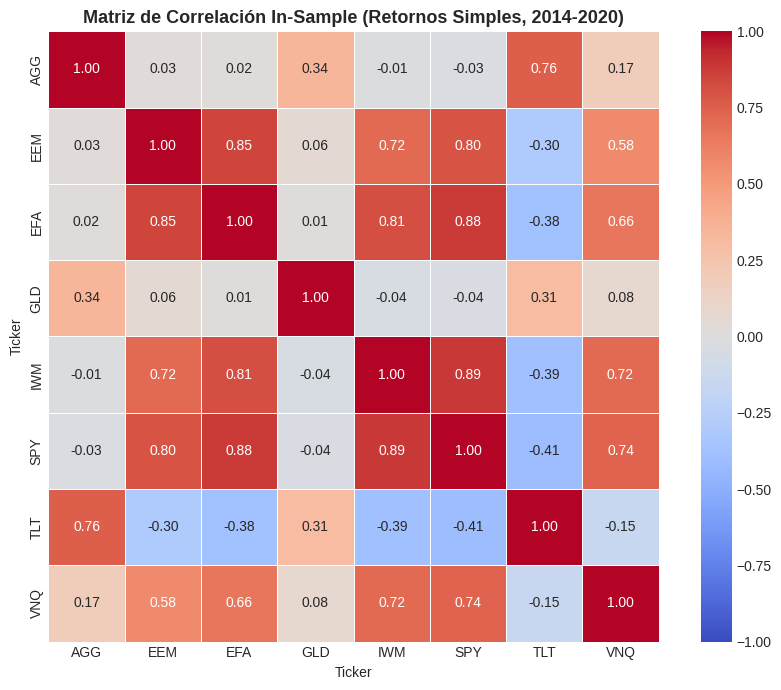

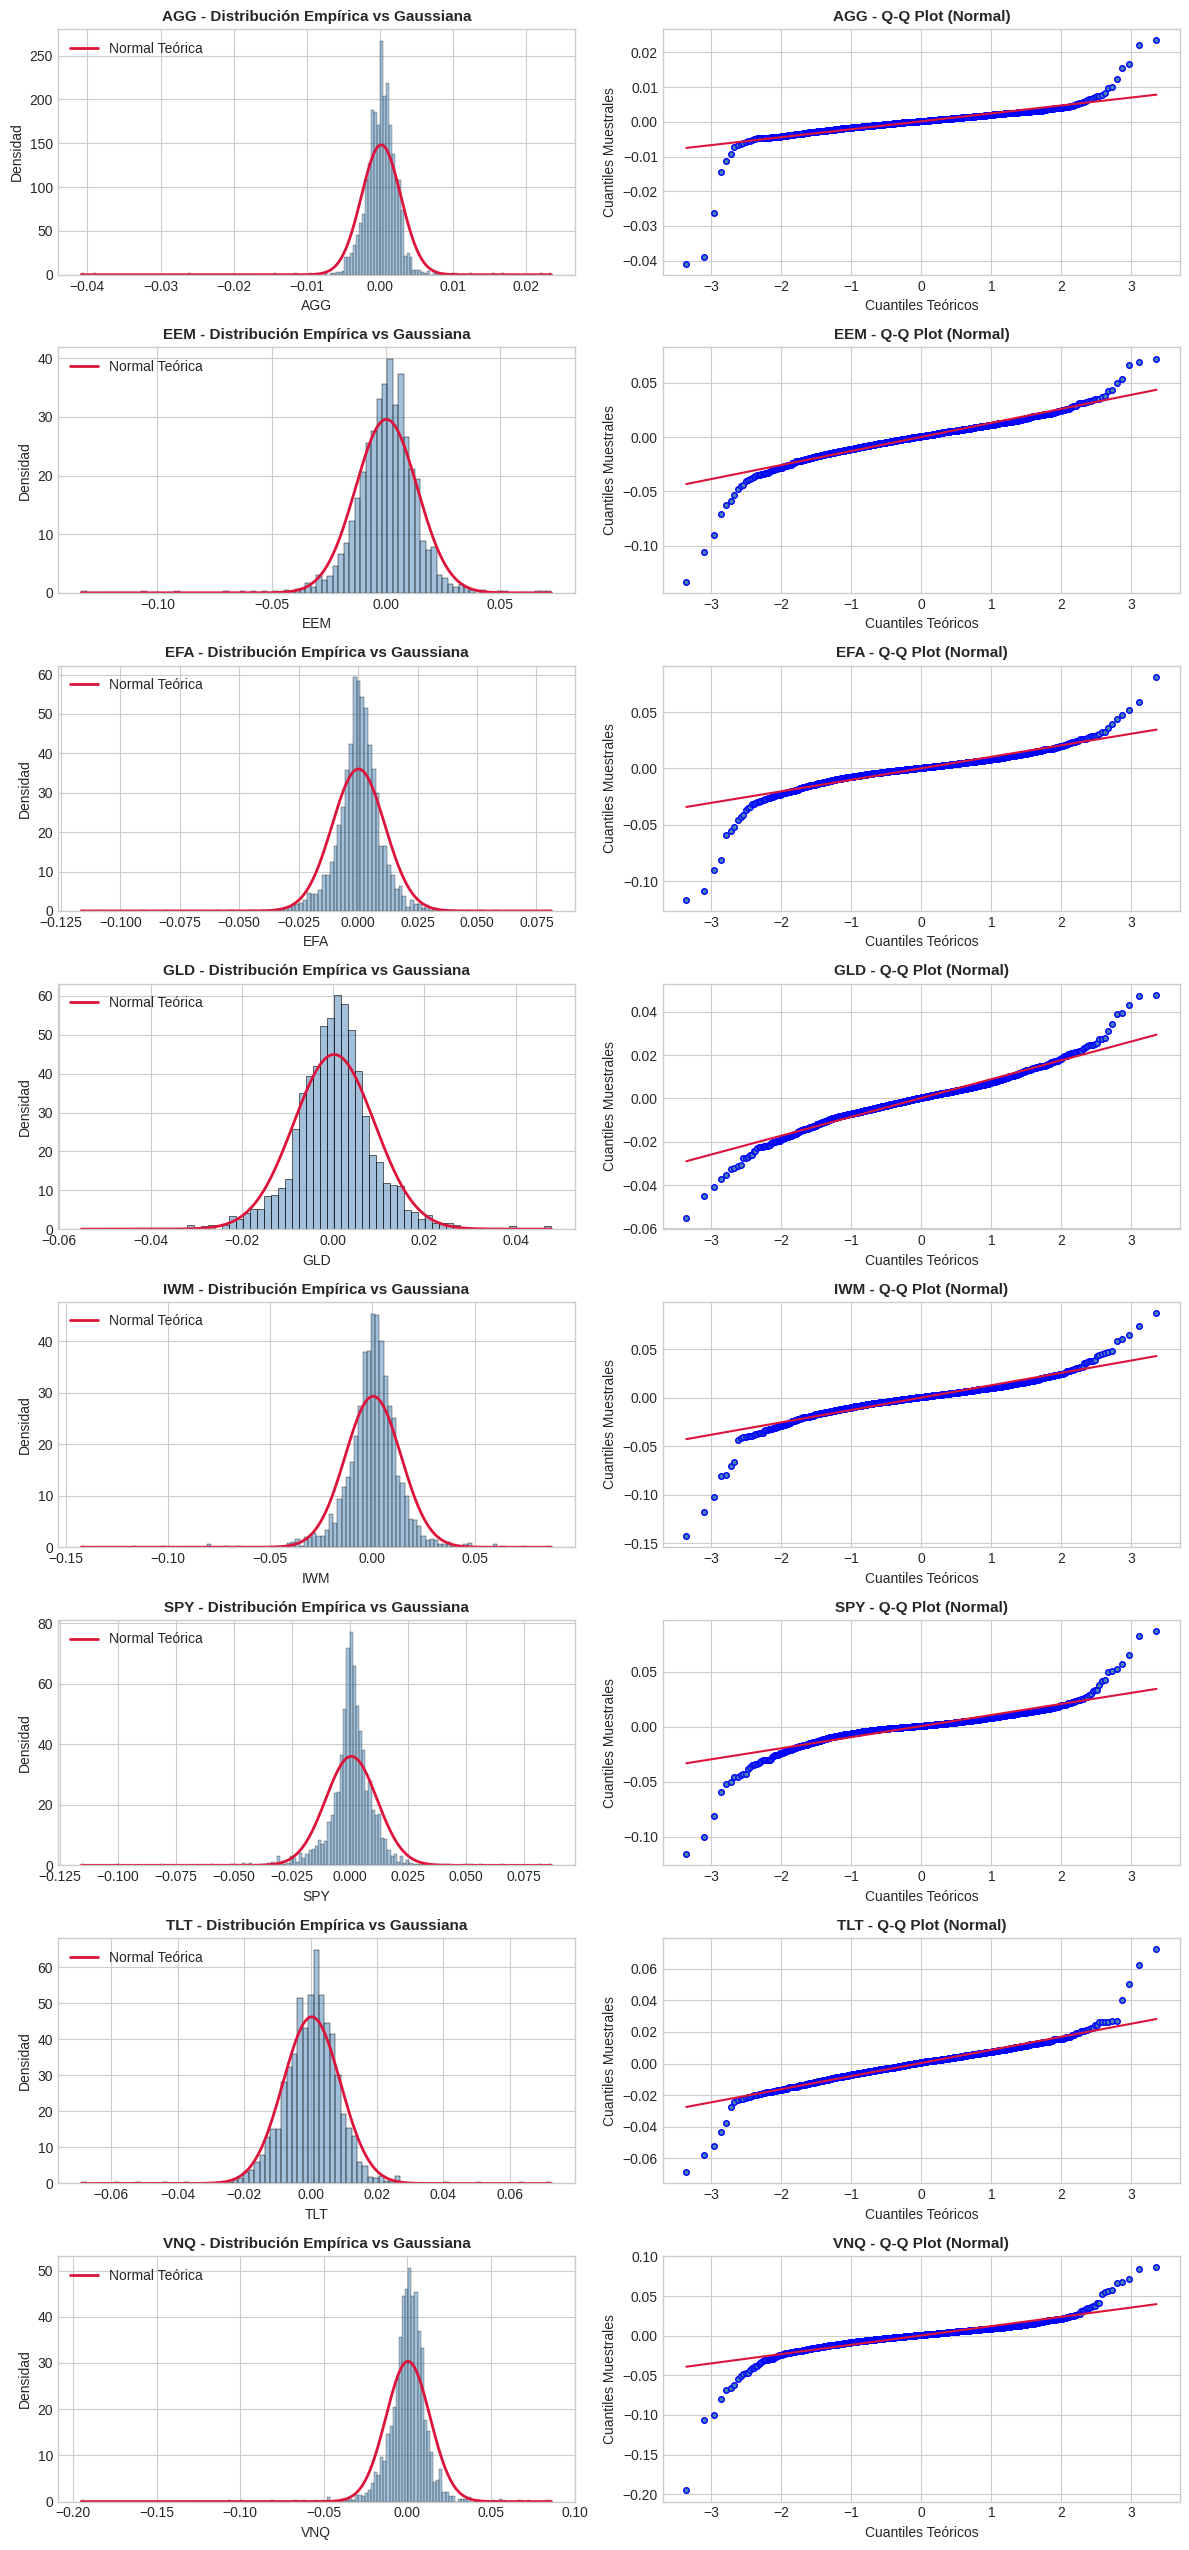

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -------------------------------------------------------------------------
# 1. PARTICIÓN TEMPORAL ESTRICTA (IN-SAMPLE VS OUT-OF-SAMPLE)
# -------------------------------------------------------------------------
SPLIT_DATE = '2020-12-31'
TRADING_DAYS = 252

# Separación de precios
prices_is = clean_prices.loc[:SPLIT_DATE].copy()
prices_oos = clean_prices.loc[SPLIT_DATE:].copy()

# Sincronización y separación de la tasa libre de riesgo (^IRX)
# Se sincronizan índices para evitar desfases de calendario
rf_series_aligned = rf_series.reindex(clean_prices.index).ffill().bfill()
rf_is_series = rf_series_aligned.loc[:SPLIT_DATE]
rf_oos_series = rf_series_aligned.loc[SPLIT_DATE:]

# Tasa libre de riesgo promedio anualizada In-Sample
rf_is_annual = float(rf_is_series.mean())


# -------------------------------------------------------------------------
# 2. MÓDULO ESTADÍSTICO Y EXPLORATORIO CORREGIDO
# -------------------------------------------------------------------------
class ReturnAnalyzer:
    """
    Módulo para el análisis estadístico riguroso de series temporales.
    Separa el análisis distribucional (Log Returns) de la optimización (Simple Returns)
    e incorpora métricas de colas pesadas y riesgo asimétrico (Drawdown).
    """
    def __init__(self, prices: pd.DataFrame, rf_annual: float):
        self.prices = prices
        self.rf_annual = rf_annual
        # Retornos Simples: Obligatorios para agregación de portafolios y covarianza
        self.simple_returns = prices.pct_change().dropna()
        # Retornos Logarítmicos: Obligatorios para tests de normalidad y series temporales
        self.log_returns = np.log(prices / prices.shift(1)).dropna()

    def compute_max_drawdown(self) -> pd.Series:
        """Calcula el máximo drawdown histórico por activo sobre la muestra analizada."""
        cumulative = (1 + self.simple_returns).cumprod()
        running_max = cumulative.cummax()
        drawdowns = (cumulative - running_max) / running_max
        return drawdowns.min()

    def descriptive_stats(self) -> pd.DataFrame:
        """
        Calcula momentos estadísticos y métricas clave anualizadas.
        - Media y Volatilidad calculadas sobre retornos simples (compatibles con Markowitz).
        - Asimetría, Curtosis y Jarque-Bera calculados sobre retornos logarítmicos.
        """
        jb_pvalues = {}
        for col in self.log_returns.columns:
            _, pval = stats.jarque_bera(self.log_returns[col])
            jb_pvalues[col] = pval

        mean_annual = self.simple_returns.mean() * TRADING_DAYS
        vol_annual = self.simple_returns.std() * np.sqrt(TRADING_DAYS)
        sharpe_individual = (mean_annual - self.rf_annual) / vol_annual

        summary = pd.DataFrame({
            "Rendimiento Medio Anual": mean_annual,
            "Volatilidad Anual (σ)": vol_annual,
            "Sharpe Ratio Ex-Ante": sharpe_individual,
            "Max Drawdown": self.compute_max_drawdown(),
            "Asimetría (Skew)": self.log_returns.skew(),
            "Exceso de Curtosis": self.log_returns.kurtosis(),
            "Jarque-Bera p-valor": pd.Series(jb_pvalues)
        })
        summary["¿Es Normal? (α=0.05)"] = summary["Jarque-Bera p-valor"] > 0.05
        return summary.round(4)

    def get_markowitz_inputs(self):
        """Retorna el vector mu y la matriz Sigma anualizada basados en retornos simples."""
        mu = self.simple_returns.mean() * TRADING_DAYS
        sigma = self.simple_returns.cov() * TRADING_DAYS
        return mu, sigma

    def correlation_matrix(self) -> pd.DataFrame:
        """Calcula la matriz de correlación empírica."""
        return self.simple_returns.corr().round(3)

    def plot_correlation_heatmap(self, title: str):
        corr = self.correlation_matrix()
        plt.figure(figsize=(9, 7))
        sns.heatmap(corr, annot=True, cmap="coolwarm", center=0,
                    vmin=-1, vmax=1, square=True, fmt=".2f", linewidths=0.5)
        plt.title(title, fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    def plot_normality_diagnostics(self):
        """
        Genera histogramas con curva teórica Gaussiana y Q-Q Plots
        para evidenciar gráficamente la presencia de colas pesadas (fat tails).
        """
        n_assets = len(self.log_returns.columns)
        fig, axes = plt.subplots(n_assets, 2, figsize=(12, 3.2 * n_assets))

        for i, col in enumerate(self.log_returns.columns):
            data = self.log_returns[col]

            # Panel izquierdo: Histograma vs Distribución Normal teórica
            sns.histplot(data, kde=False, stat="density", ax=axes[i, 0], color="steelblue", alpha=0.5)
            x_range = np.linspace(data.min(), data.max(), 200)
            norm_pdf = stats.norm.pdf(x_range, loc=data.mean(), scale=data.std())
            axes[i, 0].plot(x_range, norm_pdf, color="crimson", lw=2, label="Normal Teórica")
            axes[i, 0].set_title(f"{col} - Distribución Empírica vs Gaussiana", fontsize=11, fontweight="bold")
            axes[i, 0].set_ylabel("Densidad")
            axes[i, 0].legend(loc="upper left")

            # Panel derecho: Q-Q Plot
            stats.probplot(data, dist="norm", plot=axes[i, 1])
            axes[i, 1].get_lines()[0].set_markerfacecolor("steelblue")
            axes[i, 1].get_lines()[0].set_markersize(4.0)
            axes[i, 1].get_lines()[1].set_color("crimson")
            axes[i, 1].set_title(f"{col} - Q-Q Plot (Normal)", fontsize=11, fontweight="bold")
            axes[i, 1].set_xlabel("Cuantiles Teóricos")
            axes[i, 1].set_ylabel("Cuantiles Muestrales")

        plt.tight_layout()
        plt.show()


# -------------------------------------------------------------------------
# 3. EJECUCIÓN DEL ANÁLISIS AISLADO EN LA VENTANA IN-SAMPLE (2014-2020)
# -------------------------------------------------------------------------
analyzer_is = ReturnAnalyzer(prices=prices_is, rf_annual=rf_is_annual)

print(f"--- Parámetros In-Sample ({prices_is.index[0].date()} a {prices_is.index[-1].date()}) ---")
print(f"Tasa Libre de Riesgo Anualizada Promedio (Rf): {rf_is_annual:.4%}")
print("\n--- Tabla Estadística Descriptiva (Sin Sesgo de Look-Ahead) ---")
display_df = analyzer_is.descriptive_stats()
print(display_df.to_string())

# Extracción de parámetros que alimentarán a Monte Carlo y SciPy
mu_in_sample, cov_in_sample = analyzer_is.get_markowitz_inputs()

print("\n--- Matriz de Covarianza Anualizada (Insumo Markowitz) ---")
print((cov_in_sample * 100).round(3))

# Gráficos de correlación y colas pesadas
analyzer_is.plot_correlation_heatmap("Matriz de Correlación In-Sample (Retornos Simples, 2014-2020)")
analyzer_is.plot_normality_diagnostics()

<>:116: SyntaxWarning: invalid escape sequence '\s'
<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:116: SyntaxWarning: invalid escape sequence '\s'
<>:117: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_495/1793157218.py:116: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Volatilidad Anualizada ($\sigma_p$)', fontsize=11)
/tmp/ipykernel_495/1793157218.py:117: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Retorno Esperado Anualizado ($\mu_p$)', fontsize=11)


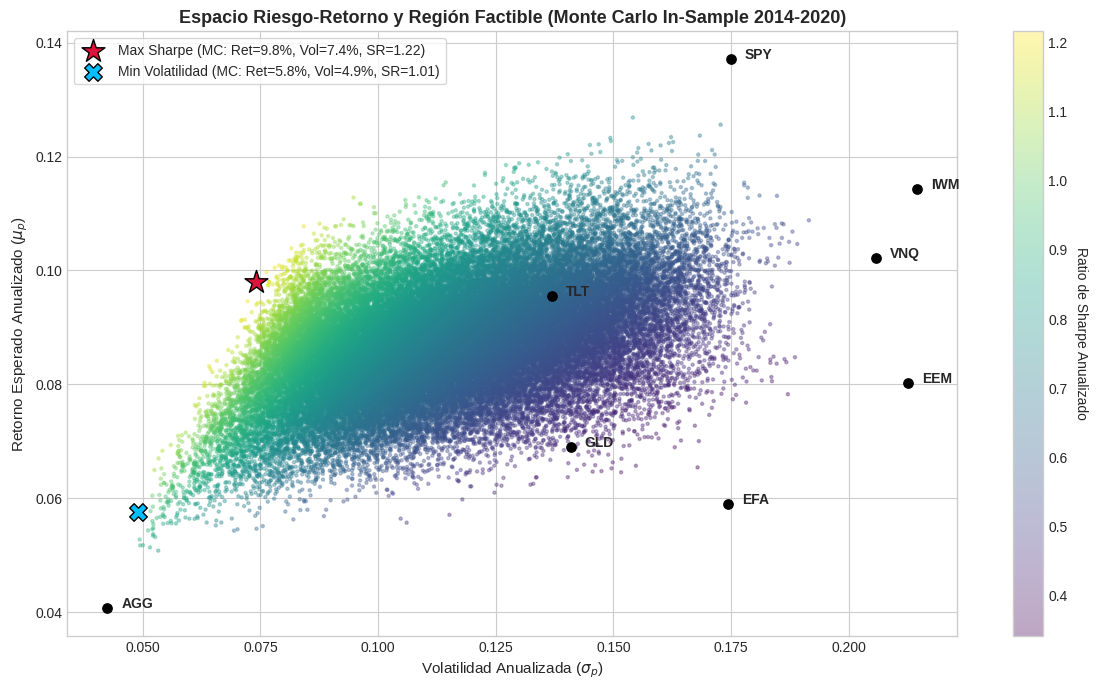


--- Pesos Aproximados por Simulación Monte Carlo (%) ---
     Min Volatilidad (MC)  Max Sharpe (MC)
AGG                 69.23            14.58
EEM                  3.56             0.60
EFA                  0.21             1.89
GLD                  8.29            13.79
IWM                  4.00             1.17
SPY                  4.86            35.29
TLT                  9.41            32.65
VNQ                  0.44             0.04


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple

class MonteCarloSimulator:
    """
    Simulación vectorial de carteras aleatorias sobre el símplex unitario
    para aproximar la región factible y fronteras de inversión (In-Sample).
    """
    def __init__(self, expected_returns: pd.Series, cov_matrix: pd.DataFrame, rf: float):
        self.mu = expected_returns.values
        self.cov = cov_matrix.values
        self.tickers = expected_returns.index.tolist()
        self.rf = rf
        self.num_assets = len(self.tickers)
        self.results_df: pd.DataFrame = None
        self.weights_record: np.ndarray = None

    def run_simulation(self, num_portfolios: int = 50000, seed: int = 42) -> pd.DataFrame:
        """
        Genera ponderaciones en el símplex unitario mediante variables exponenciales normalizadas
        (equivalente a Dirichlet(1, ..., 1)).
        """
        np.random.seed(seed)

        # Muestreo uniforme sobre el símplex
        raw_weights = np.random.exponential(scale=1.0, size=(num_portfolios, self.num_assets))
        weights = raw_weights / np.sum(raw_weights, axis=1, keepdims=True)
        self.weights_record = weights

        # Retorno esperado vectorizado: E[R_p] = w^T * mu
        portfolio_returns = np.dot(weights, self.mu)

        # Varianza vectorizada: sigma_p^2 = w^T * Sigma * w
        portfolio_variance = np.sum(np.dot(weights, self.cov) * weights, axis=1)
        portfolio_volatilities = np.sqrt(portfolio_variance)

        # Ratio de Sharpe anualizado ex-ante
        sharpe_ratios = (portfolio_returns - self.rf) / portfolio_volatilities

        self.results_df = pd.DataFrame({
            'Retorno': portfolio_returns,
            'Volatilidad': portfolio_volatilities,
            'Sharpe': sharpe_ratios
        })

        return self.results_df

    def get_optimal_approximations(self) -> Tuple[pd.Series, pd.Series]:
        """Extrae los vectores de pesos heurísticos de Mínima Varianza y Máximo Sharpe."""
        idx_max_sharpe = self.results_df['Sharpe'].idxmax()
        idx_min_vol = self.results_df['Volatilidad'].idxmin()

        max_sharpe_weights = pd.Series(
            self.weights_record[idx_max_sharpe],
            index=self.tickers,
            name="Max Sharpe (MC)"
        )
        min_vol_weights = pd.Series(
            self.weights_record[idx_min_vol],
            index=self.tickers,
            name="Min Volatilidad (MC)"
        )

        return max_sharpe_weights, min_vol_weights

    def plot_feasible_region(self, max_sharpe_w: pd.Series, min_vol_w: pd.Series):
        """Mapea la envolvente convexa y ubica los activos individuales y carteras óptimas."""
        plt.figure(figsize=(12, 7))

        # Nube de puntos de portafolios simulados
        scatter = plt.scatter(
            self.results_df['Volatilidad'],
            self.results_df['Retorno'],
            c=self.results_df['Sharpe'],
            cmap='viridis',
            alpha=0.35,
            s=5
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label('Ratio de Sharpe Anualizado', rotation=270, labelpad=15)

        # Portafolio Máximo Sharpe (MC)
        idx_ms = self.results_df['Sharpe'].idxmax()
        ms_vol = self.results_df.loc[idx_ms, 'Volatilidad']
        ms_ret = self.results_df.loc[idx_ms, 'Retorno']
        ms_sr = self.results_df.loc[idx_ms, 'Sharpe']
        plt.scatter(
            ms_vol, ms_ret,
            color='crimson', marker='*', s=300, edgecolors='black',
            label=f'Max Sharpe (MC: Ret={ms_ret:.1%}, Vol={ms_vol:.1%}, SR={ms_sr:.2f})'
        )

        # Portafolio Mínima Varianza (MC)
        idx_mv = self.results_df['Volatilidad'].idxmin()
        mv_vol = self.results_df.loc[idx_mv, 'Volatilidad']
        mv_ret = self.results_df.loc[idx_mv, 'Retorno']
        mv_sr = self.results_df.loc[idx_mv, 'Sharpe']
        plt.scatter(
            mv_vol, mv_ret,
            color='deepskyblue', marker='X', s=160, edgecolors='black',
            label=f'Min Volatilidad (MC: Ret={mv_ret:.1%}, Vol={mv_vol:.1%}, SR={mv_sr:.2f})'
        )

        # Graficar activos individuales
        individual_vols = np.sqrt(np.diag(self.cov))
        for i, ticker in enumerate(self.tickers):
            plt.scatter(individual_vols[i], self.mu[i], color='black', s=45, zorder=5)
            plt.text(
                individual_vols[i] + 0.003, self.mu[i],
                ticker, fontsize=10, fontweight='bold', zorder=5
            )

        plt.title('Espacio Riesgo-Retorno y Región Factible (Monte Carlo In-Sample 2014-2020)', fontsize=13, fontweight='bold')
        plt.xlabel('Volatilidad Anualizada ($\sigma_p$)', fontsize=11)
        plt.ylabel('Retorno Esperado Anualizado ($\mu_p$)', fontsize=11)
        plt.legend(frameon=True, loc='upper left')
        plt.tight_layout()
        plt.show()

# -------------------------------------------------------------------------
# EJECUCIÓN CON LOS INSUMOS DE LA FASE 2
# -------------------------------------------------------------------------
mc_simulator = MonteCarloSimulator(
    expected_returns=mu_in_sample,
    cov_matrix=cov_in_sample,
    rf=rf_is_annual
)

# Ejecución de 50,000 portafolios
mc_results = mc_simulator.run_simulation(num_portfolios=50000, seed=42)
w_max_sharpe_mc, w_min_vol_mc = mc_simulator.get_optimal_approximations()

# Visualización
mc_simulator.plot_feasible_region(w_max_sharpe_mc, w_min_vol_mc)

# Resumen numérico de pesos
print("\n--- Pesos Aproximados por Simulación Monte Carlo (%) ---")
weights_mc_comparison = pd.DataFrame({
    'Min Volatilidad (MC)': w_min_vol_mc * 100,
    'Max Sharpe (MC)': w_max_sharpe_mc * 100
})
print(weights_mc_comparison.round(2).to_string())

Mejor Sharpe encontrado por Monte Carlo (50,000 muestras): 1.2159
Sharpe óptimo exacto vía SciPy (SLSQP):                    1.2744
Diferencia: 0.0585 (debe ser >= 0: SciPy nunca puede ser peor que una búsqueda aleatoria)


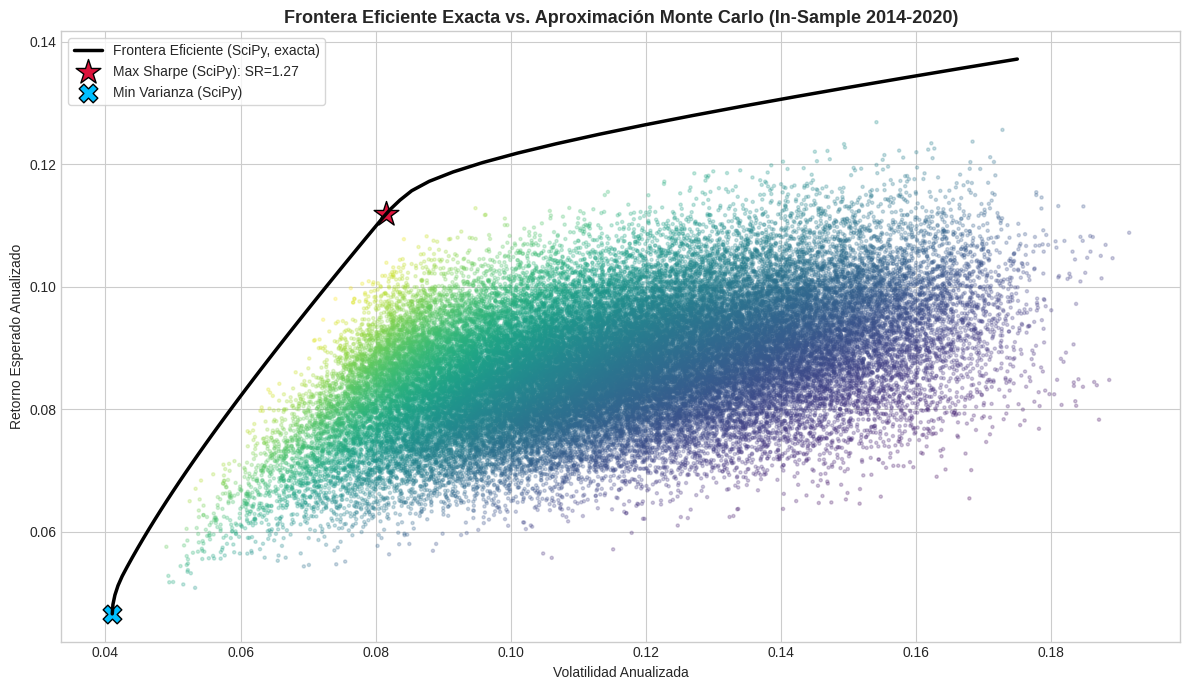


--- Pesos Óptimos (SciPy) ---
     Min Varianza  Max Sharpe
AGG        0.9386      0.0000
EEM        0.0000      0.0000
EFA        0.0000      0.0000
GLD        0.0000      0.0644
IWM        0.0000      0.0000
SPY        0.0614      0.4322
TLT        0.0000      0.5034
VNQ        0.0000      0.0000


In [5]:
from scipy.optimize import minimize

class MarkowitzOptimizer:
    """
    Optimización cuantitativa exacta (no heurística) de carteras
    Markowitz vía programación no lineal (SLSQP).
    Restricción: long-only (0 <= w_i <= 1), suma de pesos = 1.
    """
    def __init__(self, expected_returns: pd.Series, cov_matrix: pd.DataFrame, rf: float):
        self.mu = expected_returns.values
        self.cov = cov_matrix.values
        self.tickers = expected_returns.index.tolist()
        self.rf = rf
        self.n = len(self.tickers)
        self.bounds = tuple((0.0, 1.0) for _ in range(self.n))
        self._sum_to_one = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

    def _portfolio_return(self, w):
        return np.dot(w, self.mu)

    def _portfolio_vol(self, w):
        return np.sqrt(np.dot(w, np.dot(self.cov, w)))

    def _neg_sharpe(self, w):
        vol = self._portfolio_vol(w)
        return -(self._portfolio_return(w) - self.rf) / vol

    def optimize_min_variance(self) -> pd.Series:
        init = np.repeat(1.0 / self.n, self.n)
        result = minimize(self._portfolio_vol, init, method='SLSQP',
                           bounds=self.bounds, constraints=[self._sum_to_one])
        if not result.success:
            raise RuntimeError(f"Optimización Min-Varianza falló: {result.message}")
        return pd.Series(result.x, index=self.tickers, name="Min Varianza (SciPy)")

    def optimize_max_sharpe(self) -> pd.Series:
        init = np.repeat(1.0 / self.n, self.n)
        result = minimize(self._neg_sharpe, init, method='SLSQP',
                           bounds=self.bounds, constraints=[self._sum_to_one])
        if not result.success:
            raise RuntimeError(f"Optimización Max Sharpe falló: {result.message}")
        return pd.Series(result.x, index=self.tickers, name="Max Sharpe (SciPy)")

    def efficient_frontier(self, n_points: int = 60) -> pd.DataFrame:
        """Traza la frontera minimizando varianza para cada nivel de retorno objetivo."""
        min_var_ret = self._portfolio_return(self.optimize_min_variance().values)
        max_ret = self.mu.max()
        target_returns = np.linspace(min_var_ret, max_ret, n_points)

        frontier_vols = []
        init = np.repeat(1.0 / self.n, self.n)

        for target in target_returns:
            constraints = [
                self._sum_to_one,
                {'type': 'eq', 'fun': lambda w, t=target: self._portfolio_return(w) - t}
            ]
            result = minimize(self._portfolio_vol, init, method='SLSQP',
                               bounds=self.bounds, constraints=constraints)
            frontier_vols.append(result.fun if result.success else np.nan)

        return pd.DataFrame({'Retorno': target_returns, 'Volatilidad': frontier_vols}).dropna()


# --- Ejecución ---
optimizer = MarkowitzOptimizer(
    expected_returns=mu_in_sample, cov_matrix=cov_in_sample, rf=rf_is_annual
)

w_min_var = optimizer.optimize_min_variance()
w_max_sharpe = optimizer.optimize_max_sharpe()
frontier = optimizer.efficient_frontier(n_points=60)

# --- Validación cruzada contra Monte Carlo (Fase 3) ---
mc_best_sharpe = mc_results['Sharpe'].max()
scipy_sharpe = -optimizer._neg_sharpe(w_max_sharpe.values)

print(f"Mejor Sharpe encontrado por Monte Carlo (50,000 muestras): {mc_best_sharpe:.4f}")
print(f"Sharpe óptimo exacto vía SciPy (SLSQP):                    {scipy_sharpe:.4f}")
print(f"Diferencia: {scipy_sharpe - mc_best_sharpe:.4f} "
      f"(debe ser >= 0: SciPy nunca puede ser peor que una búsqueda aleatoria)")

# --- Visualización: frontera exacta sobre la nube Monte Carlo ---
plt.figure(figsize=(12, 7))
plt.scatter(mc_results['Volatilidad'], mc_results['Retorno'],
            c=mc_results['Sharpe'], cmap='viridis', alpha=0.25, s=5)
plt.plot(frontier['Volatilidad'], frontier['Retorno'],
         color='black', linewidth=2.5, label='Frontera Eficiente (SciPy, exacta)')

ms_vol = optimizer._portfolio_vol(w_max_sharpe.values)
ms_ret = optimizer._portfolio_return(w_max_sharpe.values)
mv_vol = optimizer._portfolio_vol(w_min_var.values)
mv_ret = optimizer._portfolio_return(w_min_var.values)

plt.scatter(ms_vol, ms_ret, color='crimson', marker='*', s=350,
            edgecolors='black', label=f'Max Sharpe (SciPy): SR={scipy_sharpe:.2f}')
plt.scatter(mv_vol, mv_ret, color='deepskyblue', marker='X', s=180,
            edgecolors='black', label='Min Varianza (SciPy)')

plt.title('Frontera Eficiente Exacta vs. Aproximación Monte Carlo (In-Sample 2014-2020)',
          fontsize=13, fontweight='bold')
plt.xlabel('Volatilidad Anualizada'); plt.ylabel('Retorno Esperado Anualizado')
plt.legend(frameon=True, loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Pesos Óptimos (SciPy) ---")
print(pd.DataFrame({'Min Varianza': w_min_var, 'Max Sharpe': w_max_sharpe}).round(4))

In [ ]:
from scipy.optimize import minimize

class MarkowitzOptimizer:
    """
    Optimización cuantitativa exacta (no heurística) de carteras
    Markowitz vía programación no lineal (SLSQP).
    Restricción: long-only (0 <= w_i <= 1), suma de pesos = 1.
    """
    def __init__(self, expected_returns: pd.Series, cov_matrix: pd.DataFrame, rf: float):
        self.mu = expected_returns.values
        self.cov = cov_matrix.values
        self.tickers = expected_returns.index.tolist()
        self.rf = rf
        self.n = len(self.tickers)
        self.bounds = tuple((0.0, 1.0) for _ in range(self.n))
        self._sum_to_one = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

    def _portfolio_return(self, w):
        return np.dot(w, self.mu)

    def _portfolio_vol(self, w):
        return np.sqrt(np.dot(w, np.dot(self.cov, w)))

    def _neg_sharpe(self, w):
        vol = self._portfolio_vol(w)
        return -(self._portfolio_return(w) - self.rf) / vol

    def optimize_min_variance(self) -> pd.Series:
        init = np.repeat(1.0 / self.n, self.n)
        result = minimize(self._portfolio_vol, init, method='SLSQP',
                           bounds=self.bounds, constraints=[self._sum_to_one])
        if not result.success:
            raise RuntimeError(f"Optimización Min-Varianza falló: {result.message}")
        return pd.Series(result.x, index=self.tickers, name="Min Varianza (SciPy)")

    def optimize_max_sharpe(self) -> pd.Series:
        init = np.repeat(1.0 / self.n, self.n)
        result = minimize(self._neg_sharpe, init, method='SLSQP',
                           bounds=self.bounds, constraints=[self._sum_to_one])
        if not result.success:
            raise RuntimeError(f"Optimización Max Sharpe falló: {result.message}")
        return pd.Series(result.x, index=self.tickers, name="Max Sharpe (SciPy)")

    def efficient_frontier(self, n_points: int = 60) -> pd.DataFrame:
        """Traza la frontera minimizando varianza para cada nivel de retorno objetivo."""
        min_var_ret = self._portfolio_return(self.optimize_min_variance().values)
        max_ret = self.mu.max()
        target_returns = np.linspace(min_var_ret, max_ret, n_points)

        frontier_vols = []
        init = np.repeat(1.0 / self.n, self.n)

        for target in target_returns:
            constraints = [
                self._sum_to_one,
                {'type': 'eq', 'fun': lambda w, t=target: self._portfolio_return(w) - t}
            ]
            result = minimize(self._portfolio_vol, init, method='SLSQP',
                               bounds=self.bounds, constraints=constraints)
            frontier_vols.append(result.fun if result.success else np.nan)

        return pd.DataFrame({'Retorno': target_returns, 'Volatilidad': frontier_vols}).dropna()


# --- Ejecución ---
optimizer = MarkowitzOptimizer(
    expected_returns=mu_in_sample, cov_matrix=cov_in_sample, rf=rf_is_annual
)

w_min_var = optimizer.optimize_min_variance()
w_max_sharpe = optimizer.optimize_max_sharpe()
frontier = optimizer.efficient_frontier(n_points=60)

# --- Validación cruzada contra Monte Carlo (Fase 3) ---
mc_best_sharpe = mc_results['Sharpe'].max()
scipy_sharpe = -optimizer._neg_sharpe(w_max_sharpe.values)

print(f"Mejor Sharpe encontrado por Monte Carlo (50,000 muestras): {mc_best_sharpe:.4f}")
print(f"Sharpe óptimo exacto vía SciPy (SLSQP):                    {scipy_sharpe:.4f}")
print(f"Diferencia: {scipy_sharpe - mc_best_sharpe:.4f} "
      f"(debe ser >= 0: SciPy nunca puede ser peor que una búsqueda aleatoria)")

# --- Visualización: frontera exacta sobre la nube Monte Carlo ---
plt.figure(figsize=(12, 7))
plt.scatter(mc_results['Volatilidad'], mc_results['Retorno'],
            c=mc_results['Sharpe'], cmap='viridis', alpha=0.25, s=5)
plt.plot(frontier['Volatilidad'], frontier['Retorno'],
         color='black', linewidth=2.5, label='Frontera Eficiente (SciPy, exacta)')

ms_vol = optimizer._portfolio_vol(w_max_sharpe.values)
ms_ret = optimizer._portfolio_return(w_max_sharpe.values)
mv_vol = optimizer._portfolio_vol(w_min_var.values)
mv_ret = optimizer._portfolio_return(w_min_var.values)

plt.scatter(ms_vol, ms_ret, color='crimson', marker='*', s=350,
            edgecolors='black', label=f'Max Sharpe (SciPy): SR={scipy_sharpe:.2f}')
plt.scatter(mv_vol, mv_ret, color='deepskyblue', marker='X', s=180,
            edgecolors='black', label='Min Varianza (SciPy)')

plt.title('Frontera Eficiente Exacta vs. Aproximación Monte Carlo (In-Sample 2014-2020)',
          fontsize=13, fontweight='bold')
plt.xlabel('Volatilidad Anualizada'); plt.ylabel('Retorno Esperado Anualizado')
plt.legend(frameon=True, loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Pesos Óptimos (SciPy) ---")
print(pd.DataFrame({'Min Varianza': w_min_var, 'Max Sharpe': w_max_sharpe}).round(4))

In [ ]:
# 1. Configuración de pesos para las estrategias
w_eq = pd.Series(1.0 / len(prices_oos.columns), index=prices_oos.columns)
w_spy = pd.Series(0.0, index=prices_oos.columns)
w_spy['SPY'] = 1.0

# 2. Inicialización del motor con tasa Rf de prueba
rf_oos_annual = float(rf_oos_series.mean())
backtester = PortfolioBacktester(prices=prices_oos, rf_annual=rf_oos_annual, transaction_cost_bps=10.0)

# 3. Simulación de curvas de capital
curves = {
    'Max Sharpe (SciPy)': backtester.run_strategy(w_max_sharpe),
    'Min Varianza (SciPy)': backtester.run_strategy(w_min_var),
    'Equally Weighted (1/N)': backtester.run_strategy(w_eq),
    'Benchmark (SPY)': backtester.run_strategy(w_spy)
}

# 4. Tabla de rendimiento
perf_table = backtester.evaluate_performance(curves)
print(f"--- Rendimiento Out-of-Sample (2021-01 a 2023-12 | Rf: {rf_oos_annual:.2%}) ---")
print(perf_table.to_string())

# 5. Visualización: Curva de Capital y Drawdown Subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

colors = {'Max Sharpe (SciPy)': 'crimson', 'Min Varianza (SciPy)': 'deepskyblue',
          'Equally Weighted (1/N)': 'darkorange', 'Benchmark (SPY)': 'black'}

for name, curve in curves.items():
    ax1.plot(curve, label=name, color=colors[name], lw=1.8 if name != 'Benchmark (SPY)' else 2.2)
    running_max = curve.cummax()
    dd = (curve - running_max) / running_max * 100
    ax2.plot(dd, label=name, color=colors[name], lw=1.2)

ax1.set_title('Evolución de Riqueza Out-of-Sample (Base 100)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Valor de la Cartera ($)')
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.3)

ax2.set_title('Perfil de Drawdown (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Caída Pico-Valle (%)')
ax2.set_xlabel('Fecha')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

# -------------------------------------------------------------------------
# 1. ESTIMACIÓN DE COVARIANZA: MUESTRAL VS LEDOIT-WOLF
# -------------------------------------------------------------------------
# Retornos simples In-Sample
returns_is = prices_is.pct_change().dropna()
n_obs, n_assets = returns_is.shape

# Ajuste de Ledoit-Wolf vía scikit-learn
lw = LedoitWolf(assume_centered=False)
lw.fit(returns_is.values)

# Matriz regularizada anualizada e intensidad de contracción óptima
cov_lw_annual = pd.DataFrame(lw.covariance_ * TRADING_DAYS, index=cov_in_sample.index, columns=cov_in_sample.columns)
shrinkage_intensity = lw.shrinkage_

print(f"--- Diagnóstico de Matrices de Covarianza ---")
print(f"Intensidad de Contracción Óptima (Delta*): {shrinkage_intensity:.4f}")
print(f"Número de Condición Matriz Muestral:       {np.linalg.cond(cov_in_sample.values):.2f}")
print(f"Número de Condición Matriz Ledoit-Wolf:    {np.linalg.cond(cov_lw_annual.values):.2f}")

# -------------------------------------------------------------------------
# 2. COMPARATIVA DE PESOS ÓPTIMOS (MUESTRAL VS LEDOIT-WOLF)
# -------------------------------------------------------------------------
opt_sample = MarkowitzOptimizer(mu_in_sample, cov_in_sample, rf_is_annual)
opt_lw = MarkowitzOptimizer(mu_in_sample, cov_lw_annual, rf_is_annual)

w_ms_sample = opt_sample.optimize_max_sharpe()
w_ms_lw = opt_lw.optimize_max_sharpe()

w_mv_sample = opt_sample.optimize_min_variance()
w_mv_lw = opt_lw.optimize_min_variance()

weights_robustness = pd.DataFrame({
    'Min Var (Muestral)': w_mv_sample * 100,
    'Min Var (Ledoit-Wolf)': w_mv_lw * 100,
    'Max Sharpe (Muestral)': w_ms_sample * 100,
    'Max Sharpe (Ledoit-Wolf)': w_ms_lw * 100
})
print("\n--- Comparativa de Asignación de Capital (%) ---")
print(weights_robustness.round(2).to_string())

# -------------------------------------------------------------------------
# 3. ANÁLISIS DE SENSIBILIDAD POR PERTURBACIÓN ESTOCÁSTICA (MICHAUD RESAMPLING)
# -------------------------------------------------------------------------
def simulate_parameter_uncertainty(mu: pd.Series, cov: pd.DataFrame, rf: float, n_simulations: int = 500):
    """
    Evalúa la inestabilidad de los pesos de Máximo Sharpe simulando
    el error de estimación estándar en el vector de retornos esperados.
    """
    np.random.seed(42)
    tickers = mu.index.tolist()
    n = len(tickers)

    # Matriz de covarianza del error de estimación de la media: Sigma / T
    cov_error = cov.values / (n_obs / TRADING_DAYS)

    simulated_weights = []

    for _ in range(n_simulations):
        # Muestra perturbada del vector mu
        mu_perturbed = np.random.multivariate_normal(mu.values, cov_error)

        # Optimización sobre escenario perturbado
        opt_temp = MarkowitzOptimizer(pd.Series(mu_perturbed, index=tickers), cov, rf)
        try:
            w_opt = opt_temp.optimize_max_sharpe().values
            simulated_weights.append(w_opt)
        except RuntimeError:
            continue

    df_sim_weights = pd.DataFrame(simulated_weights, columns=tickers)
    return df_sim_weights

df_resampled_weights = simulate_parameter_uncertainty(mu_in_sample, cov_in_sample, rf_is_annual)

# -------------------------------------------------------------------------
# 4. VISUALIZACIÓN DE ROBUSTEZ E INCERTIDUMBRE
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Fronteras Eficientes (Muestral vs Ledoit-Wolf)
frontier_sample = opt_sample.efficient_frontier(n_points=60)
frontier_lw = opt_lw.efficient_frontier(n_points=60)

ax1.plot(frontier_sample['Volatilidad'], frontier_sample['Retorno'],
         label='Frontera Muestral Empírica', color='black', lw=2)
ax1.plot(frontier_lw['Volatilidad'], frontier_lw['Retorno'],
         label=f'Frontera Ledoit-Wolf (δ*={shrinkage_intensity:.2f})', color='royalblue', lw=2, linestyle='--')
ax1.scatter(opt_sample._portfolio_vol(w_ms_sample.values), opt_sample._portfolio_return(w_ms_sample.values),
            color='crimson', marker='*', s=250, label='Max Sharpe Muestral', zorder=5)
ax1.scatter(opt_lw._portfolio_vol(w_ms_lw.values), opt_lw._portfolio_return(w_ms_lw.values),
            color='gold', marker='*', s=250, edgecolors='black', label='Max Sharpe Ledoit-Wolf', zorder=5)

ax1.set_title('Impacto de Regularización de Covarianza', fontsize=12, fontweight='bold')
ax1.set_xlabel('Volatilidad Anualizada')
ax1.set_ylabel('Retorno Esperado Anualizado')
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# Subplot 2: Dispersión de Pesos bajo Error de Estimación (Boxplot)
(df_resampled_weights * 100).boxplot(ax=ax2, grid=True, patch_artist=True,
                                     boxprops=dict(facecolor='lightblue', color='blue'),
                                     medianprops=dict(color='crimson', lw=2))

ax2.set_title('Inestabilidad de Pesos de Máximo Sharpe (500 Muestras Perturbadas)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ponderación Asignada (%)')
ax2.set_xlabel('Activo')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 5. EVALUACIÓN OUT-OF-SAMPLE CON PESOS REGULARIZADOS
# -------------------------------------------------------------------------
curves_robustness = {
    'Max Sharpe (Muestral)': backtester.run_strategy(w_ms_sample),
    'Max Sharpe (Ledoit-Wolf)': backtester.run_strategy(w_ms_lw),
    'Min Varianza (Muestral)': backtester.run_strategy(w_mv_sample),
    'Min Varianza (Ledoit-Wolf)': backtester.run_strategy(w_mv_lw)
}

perf_robustness = backtester.evaluate_performance(curves_robustness)
print("\n--- Rendimiento Out-of-Sample: Muestral vs Regularizado ---")
print(perf_robustness.to_string())